# Model Evaluation - Phase 1 Summary

Deep-dive evaluation of the trained Random Forest and Logistics Regression classifiers. Focuses on error analysis, per-class performance, and saving final artifacts. Models are loaded from 'artifacts/models/' - run '03_model_training.ipynb' first if they don't exist locally.

In [1]:
import sys
sys.path.insert(0, "../..")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.data.preprocess import load_and_clean, encode_features, get_feature_names
from src.models.evaluate import evaluate_model, plot_feature_importance

sns.set_theme(style="whitegrid", palette="muted")

root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
models_path = root / "artifacts" / "models"
figures_path = root / "artifacts" / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

df = load_and_clean(path=str(root / "data" / "processed" / "cat_behavior_clean.csv"))
X, y, cat_enc, label_enc = encode_features(df)
label_names = label_enc.classes_.tolist()
feature_names = get_feature_names()

rf = joblib.load(models_path / "rf_model.pkl")
lr = joblib.load(models_path / "logreg_model.pkl")

from sklearn.model_selection import train_test_split
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Loaded successfully.")
print(f"Test set: {len(X_test)} rows | Classes: {label_names}")

Loaded successfully.
Test set: 400 rows | Classes: ['anxious', 'grumpy', 'happy', 'playful', 'sleepy']


## Confusion Matrices


Random Forest (Tuned)
              precision    recall  f1-score   support

     anxious       0.83      0.82      0.83        85
      grumpy       0.88      0.87      0.87        82
       happy       0.93      0.93      0.93        82
     playful       0.76      0.85      0.80        80
      sleepy       0.83      0.75      0.79        71

    accuracy                           0.84       400
   macro avg       0.85      0.84      0.84       400
weighted avg       0.85      0.84      0.84       400



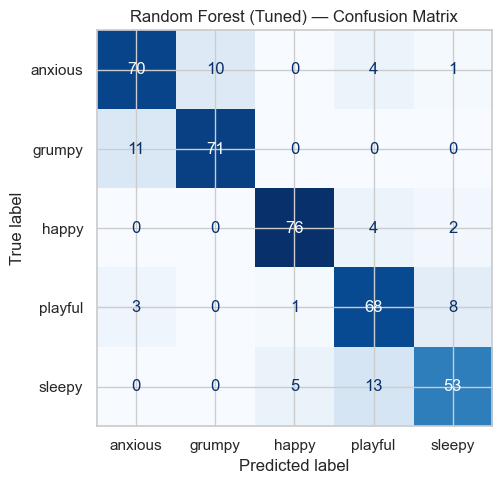

Saved → artifacts/figures/confusion_matrix_rf.png


In [2]:
fig_rf, y_pred_rf = evaluate_model(rf, X_test, y_test, label_names, "Random Forest (Tuned)")
fig_rf.savefig(figures_path / "confusion_matrix_rf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → artifacts/figures/confusion_matrix_rf.png")


Logistic Regression
              precision    recall  f1-score   support

     anxious       0.66      0.71      0.68        85
      grumpy       0.80      0.74      0.77        82
       happy       0.88      0.88      0.88        82
     playful       0.74      0.76      0.75        80
      sleepy       0.77      0.75      0.76        71

    accuracy                           0.77       400
   macro avg       0.77      0.77      0.77       400
weighted avg       0.77      0.77      0.77       400



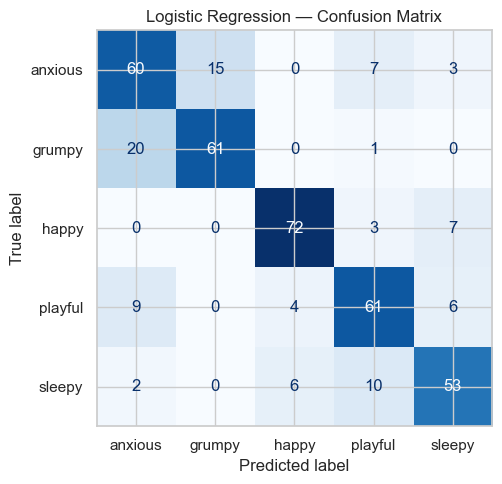

Saved → artifacts/figures/confusion_matrix_lr.png


In [3]:
fig_lr, y_pred_lr = evaluate_model(lr, X_test, y_test, label_names, "Logistic Regression")
fig_lr.savefig(figures_path / "confusion_matrix_lr.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → artifacts/figures/confusion_matrix_lr.png")

## Feature Importance

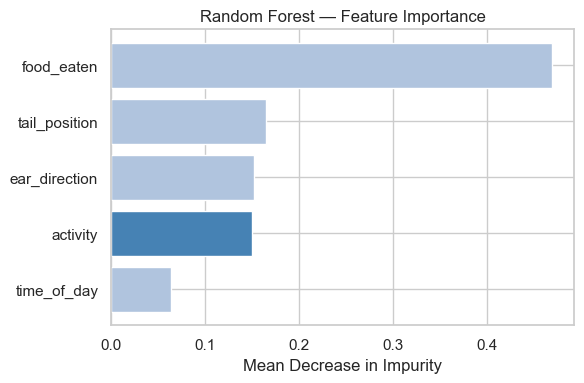

Saved → artifacts/figures/feature_importance.png


In [4]:
fig_fi = plot_feature_importance(rf, feature_names)
fig_fi.savefig(figures_path / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → artifacts/figures/feature_importance.png")

## Error Analysis

Which specific samples did the model get wrong, and why?
Looking at misclassified rows to understand the model's failure modes. 

In [5]:
df_test = df.iloc[
    train_test_split(range(len(df)), test_size=0.2, random_state=42, stratify=y)[1]
    ].copy().reset_index(drop=True)

df_test["predicted_rf"] = label_enc.inverse_transform(y_pred_rf)
df_test["correct"] = df_test["mood"] == df_test["predicted_rf"]

errors = df_test[~df_test["correct"]]
print(f"Total errors: {len(errors)} / {len(df_test)} ({len(errors) / len(df_test)*100:.1f}%)")
print(f"\nMost common mistakes:")
errors.groupby(["mood", "predicted_rf"]).size().sort_values(ascending=False).head(10)

Total errors: 62 / 400 (15.5%)

Most common mistakes:


mood     predicted_rf
sleepy   playful         13
grumpy   anxious         11
anxious  grumpy          10
playful  sleepy           8
sleepy   happy            5
anxious  playful          4
happy    playful          4
playful  anxious          3
happy    sleepy           2
anxious  sleepy           1
dtype: int64

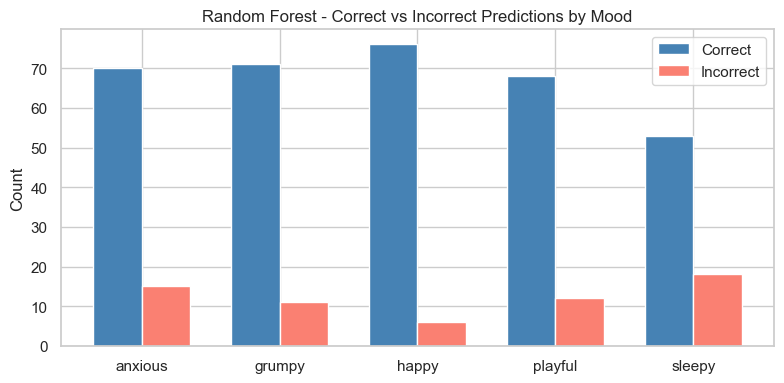

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
error_counts = errors["mood"].value_counts()
correct_counts = df_test[df_test["correct"]] ["mood"].value_counts()

x = np.arange(len(label_names))
width = 0.35

ax.bar(x - width/2, [correct_counts.get(m, 0) for m in label_names],
       width, label="Correct", color="steelblue")
ax.bar(x + width/2, [error_counts.get(m, 0) for m in label_names],
       width, label="Incorrect", color="salmon")

ax.set_xticks(x)
ax.set_xticklabels(label_names)
ax.set_ylabel("Count")
ax.set_title("Random Forest - Correct vs Incorrect Predictions by Mood")
ax.legend()
plt.tight_layout()
fig.savefig(figures_path / "error_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Misclassified Sample Profiles

What do the wrong predictions actually look like?
Spot-checking the anxious/grumpy confusion specifically.

In [7]:
mask = (errors["mood"] == "anxious") & (errors["predicted_rf"] == "grumpy") | \
       (errors["mood"] == "grumpy")  & (errors["predicted_rf"] == "anxious")

confused = errors[mask][["time_of_day", "activity", "tail_position",
                          "ear_direction", "food_eaten", "mood", "predicted_rf"]]
print(f"anxious ↔ grumpy confusions: {len(confused)}")
confused.head(10)

anxious ↔ grumpy confusions: 21


,time_of_day,activity,tail_position,ear_direction,food_eaten,mood,predicted_rf
3,12.0,2.0,3.0,1.0,0.24,grumpy,anxious
16,13.3,2.0,1.0,2.0,0.19,grumpy,anxious
18,22.5,2.0,1.0,2.0,0.14,grumpy,anxious
45,23.5,5.0,3.0,2.0,0.30,grumpy,anxious
77,20.3,3.0,0.0,1.0,0.20,anxious,grumpy
91,8.0,1.0,1.0,0.0,0.22,anxious,grumpy
99,2.0,2.0,4.0,0.0,0.18,grumpy,anxious
101,20.3,2.0,2.0,1.0,0.16,anxious,grumpy
126,8.1,0.0,4.0,2.0,0.10,anxious,grumpy
165,13.2,2.0,0.0,0.0,0.25,anxious,grumpy


## Model Comparison Summary

In [8]:
from sklearn.metrics import accuracy_score, f1_score

summary = pd.DataFrame({
    "Model": ["Random Forest (tuned)", "Logistic Regression"],
    "Accuracy": [
        round(accuracy_score(y_test, y_pred_rf), 3), 
        round(accuracy_score(y_test, y_pred_lr), 3),
    ],
    "Macro F1": [
        round(f1_score(y_test, y_pred_rf, average="macro"), 3),
        round(f1_score(y_test, y_pred_lr, average="macro"), 3), 
    ],
    "Worst Class (F1)": [
        label_names[np.argmin(f1_score(y_test, y_pred_rf, average=None))],
        label_names[np.argmin(f1_score(y_test, y_pred_lr, average=None))],
    ]
})
summary

,Model,Accuracy,Macro F1,Worst Class (F1)
0,Random Forest (tuned),0.845,0.843,sleepy
1,Logistic Regression,0.767,0.768,anxious


## Phase 1 Conclusions

**What the model learned:**
- 'food_eaten' is the single strongest predictor (~0.46 importance), creating a near-linear separation between 'happy' (high food) and 'grumpy' (low food)
- The 'anxious'/'grumpy' boundary is the primary failure mode for both models - both moods share low food intake, hiding behavior, and defensive postures
- 'time_of_day' contributes weakly but non-zero signal - the RF extracts marginal value even from features with no direct rule bias


**Baseline for Phase 3 RL agent:**
- Target to beat: RF accuracy **[0.845]**, macro F1 **[0.843]**
- Primary improvement opportunity: 'anxious'/'grumpy' confusion ([21] misclassifications out of 400 test samples)

**What's next (Phase 2):**
- Deploy model via Streamlit with a cat sprite UI
- Implement user feedback loop to capture corrections
- XP system tied to prediction accuracy